In [1]:
# First of all, check if the reovery is stable over different seeds

In [70]:
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
from tqdm import tqdm
from sklearn.linear_model import LogisticRegression

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset

device = torch.device('cuda')
device

device(type='cuda')

In [73]:
def generate_sources(k=2, m=3, seed=42, n_points=32):
    # make sources
    z_01 = np.linspace(0, 1, n_points)
    
    # modify density
    z_01 = z_01 ** 2

    ## So far this works only for k=2 because we're generating by 2d planes
    # assert k=2

    z_01 = np.meshgrid(z_01, z_01)
    z_01 = np.stack(z_01, 0).reshape(2, -1).T
    z_01 = np.concatenate([z_01, np.zeros_like(z_01[:, :1])], 1)

    count = k
    zs = [z_01]
    while count <= m:
        zs.append(np.stack([z_01[:, 0], z_01[:, 2], z_01[:, 1]], 1) )        

        count +=1
        
        z_02 = np.stack([z_01[:, 0], z_01[:, 2], z_01[:, 1]], 1)
        z_12 = np.stack([z_01[:, 2], z_01[:, 0], z_01[:, 1]], 1)
        
        z_01.shape, z_02.shape, z_12.shape

In [ ]:
z_12 = np.stack([z_01[:, 2], z_01[:, 0], z_01[:, 1]], 1)

In [74]:
z_01 = np.linspace(0, 1, 32)

In [75]:
z_01.shape

(32,)

In [7]:
z_01 = z_01 ** 2

(array([10.,  4.,  3.,  3.,  2.,  3.,  1.,  2.,  2.,  2.]),
 array([0. , 0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9, 1. ]),
 <BarContainer object of 10 artists>)

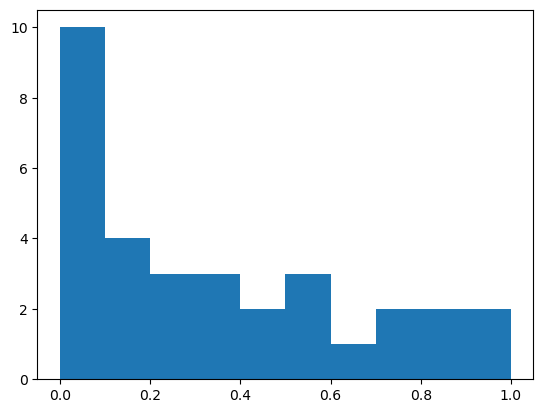

In [8]:
plt.hist(z_01)

In [9]:
z_01.shape

(32,)

In [79]:
z_01 = np.meshgrid(z_01, z_01)

In [81]:
len(z_01)

2

In [83]:
z_01[0].shape

(2048, 2048)

In [15]:
z_01 = np.stack(z_01, 0).reshape(2, -1).T

In [16]:
z_01.shape

(1024, 2)

In [17]:
z_01 = np.concatenate([z_01, np.zeros_like(z_01[:, :1])], 1)

In [18]:
z_01.shape

(1024, 3)

In [21]:
z_01

array([[0.        , 0.        , 0.        ],
       [0.00104058, 0.        , 0.        ],
       [0.00416233, 0.        , 0.        ],
       ...,
       [0.87513007, 1.        , 0.        ],
       [0.93652445, 1.        , 0.        ],
       [1.        , 1.        , 0.        ]])

In [22]:
z_02 = np.stack([z_01[:, 0], z_01[:, 2], z_01[:, 1]], 1)

In [23]:
z_02.shape

(1024, 3)

In [24]:
z_02

array([[0.        , 0.        , 0.        ],
       [0.00104058, 0.        , 0.        ],
       [0.00416233, 0.        , 0.        ],
       ...,
       [0.87513007, 0.        , 1.        ],
       [0.93652445, 0.        , 1.        ],
       [1.        , 0.        , 1.        ]])

In [25]:
z_12 = np.stack([z_01[:, 2], z_01[:, 0], z_01[:, 1]], 1)

In [27]:
z_12

array([[0.        , 0.        , 0.        ],
       [0.        , 0.00104058, 0.        ],
       [0.        , 0.00416233, 0.        ],
       ...,
       [0.        , 0.87513007, 1.        ],
       [0.        , 0.93652445, 1.        ],
       [0.        , 1.        , 1.        ]])

In [28]:
z_12.shape

(1024, 3)

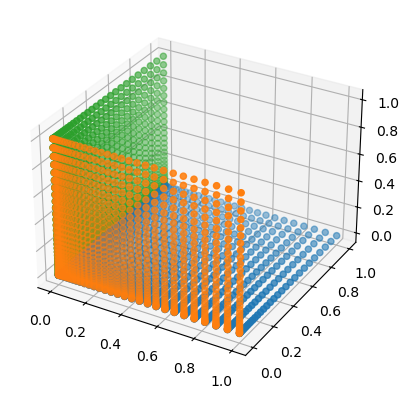

In [29]:
fig = plt.figure()
ax = fig.add_subplot(projection='3d')
ax.scatter(*z_01.T)
ax.scatter(*z_02.T)
ax.scatter(*z_12.T)

In [30]:
z_01 == z_02

array([[ True,  True,  True],
       [ True,  True,  True],
       [ True,  True,  True],
       ...,
       [ True, False, False],
       [ True, False, False],
       [ True, False, False]])

In [39]:
z_01[2]

array([0.00416233, 0.        , 0.        ])

In [40]:
z_02[2]

array([0.00416233, 0.        , 0.        ])

In [41]:
z_12[2]

array([0.        , 0.00416233, 0.        ])

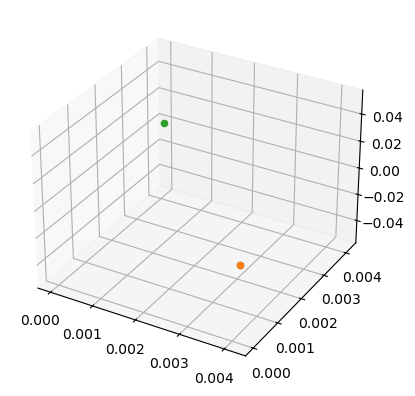

In [51]:
fig = plt.figure()
ax = fig.add_subplot(projection='3d')
ax.scatter(*z_01[2].T)
ax.scatter(*z_02[2].T)
ax.scatter(*z_12[2].T)

In [53]:
z_01 = np.concatenate([z_01, np.zeros_like(z_01[:, :1])], 1)

In [54]:
z_01.shape

(1024, 4)

In [102]:

def generate_sources(k=2, m=3, seed=42, n_points=32):
    """
    Generate n_points of k-sparse vectors of dimension m.

    Args:
        k (int): Number of non-zero entries in each vector.
        m (int): Dimensionality of each vector.
        seed (int): Random seed for reproducibility.
        n_points (int): Number of sparse vectors to generate.

    Returns:
        np.ndarray: Array of shape (n_points, m) with k-sparse vectors.
    """
    assert 0 < k <= m, "k must be between 1 and m"
    rng = np.random.default_rng(seed)
    # np.random.seed(seed)
    sources = np.zeros((n_points, m))

    for i in range(n_points):
        indices = rng.choice(m, size=k, replace=False)  # Random k positions
        values = rng.uniform(low=0.0, high=1.0, size=k)
        sources[i, indices] = values

    return sources


In [139]:
import numpy as np
import itertools

def generate_sources(k=2, m=3, seed=42, n_points=32):
    """
    Generate n_points of k-sparse vectors of dimension m,
    where each vector has non-zero entries aligned with a pair of coordinate axes.

    Args:
        k (int): Number of non-zero entries (should be 2 for pairwise axis alignment).
        m (int): Dimensionality of each vector.
        seed (int): Random seed for reproducibility.
        n_points (int): Number of sparse vectors to generate.

    Returns:
        np.ndarray: Array of shape (n_points, m) with k-sparse vectors.
    """
    assert k == 2, "Currently only supports k=2 for axis-aligned pairs"
    assert m >= 2, "Dimensionality must be at least 2"
    
    rng = np.random.default_rng(seed)
    sources = np.zeros((n_points, m))

    axis_pairs = list(itertools.combinations(range(m), k))  # All (m choose 2) axis pairs
    # print("axis_pairs", axis_pairs)
    for i in range(n_points):
        i1, i2 = axis_pairs[rng.integers(0, len(axis_pairs))]  # Choose a random pair
        # print("i1, i2", i1, i2)
        values = rng.uniform(low=0.0, high=1.0, size=2)
        sources[i, [i1, i2]] = values

    return sources


In [142]:
z_true[0:5]

array([[0.43887844, 0.85859792, 0.        ],
       [0.        , 0.69736803, 0.09417735],
       [0.7611397 , 0.        , 0.78606431],
       [0.        , 0.12811363, 0.45038594],
       [0.92676499, 0.        , 0.64386512]])

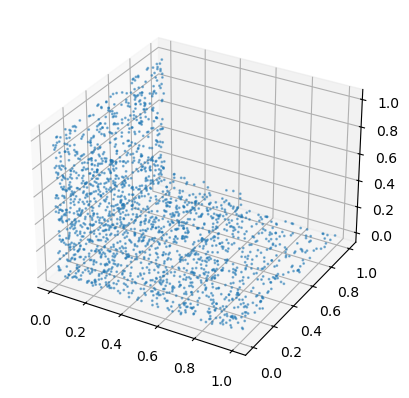

In [149]:
fig = plt.figure()
ax = fig.add_subplot(projection='3d')
ax.scatter(*z_true.T, alpha=0.5, s=1)
# ax.scatter(*z_02.T)
# ax.scatter(*z_12.T)